# Проект - определение возраста покупателей

## Описание проекта:
Сетевой супермаркет **«Хлеб-Соль»** внедряет систему компьютерного зрения для обработки фотографий покупателей.  Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:
- Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
- Контролировать добросовестность кассиров при продаже алкоголя.

## Цель проекта:
Построить модель, которая по фотографии определит приблизительный возраст человека.

## План проекта:
1. Исследовательский анализ данных
2. Подготовка данных к обучению
3. Обучение нейронной сети
4. Итоговый вывод

## Описание данных:
Данные взяты с сайта ChaLearn Looking at People.  
В нашем распоряжении одна папка со всеми изображениями (/final_files) и CSV-файл labels.csv с двумя колонками: file_name и real_age. 

### 1. Исследовательский анализ данных

Проведем исследовательский анализ данных:
Посмотрим на размер выборки.
Построим график распределения возраста в выборке.
Напечатаем на экране 10–15 фотографий и посмотрим, как устроен датасет.
Сделаем выводы о том, как результаты исследования повлияют на обучение модели.

In [1]:
# загрузка библиотек

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [2]:
# загрузка датасета

labels_df = pd.read_csv('/datasets/faces/labels.csv')

In [3]:
# просмотр датасета

print("Размер датасета (строки, колонки):", labels_df.shape)
print('--' * 25)
print("\nПервые 5 строк:")
print(labels_df.head())
print('--' * 25)
print("\nИнформация о данных:")
print(labels_df.info())

Размер датасета (строки, колонки): (7591, 2)
--------------------------------------------------

Первые 5 строк:
    file_name  real_age
0  000000.jpg         4
1  000001.jpg        18
2  000002.jpg        80
3  000003.jpg        50
4  000004.jpg        17
--------------------------------------------------

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB
None


Имеем датасет на 7591 строк и 2 столбца. Пропусков нет.

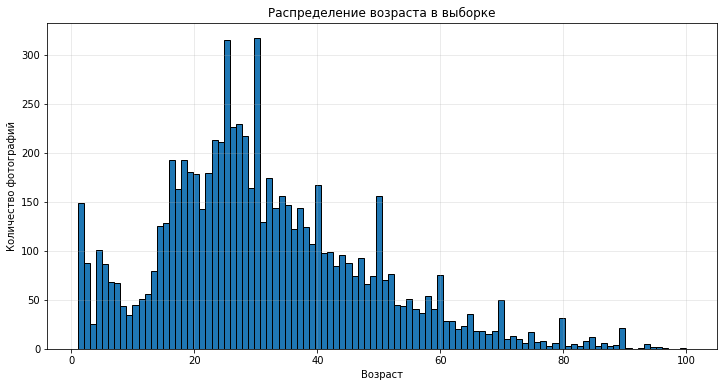

Статистика возраста:
count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64

Минимальный возраст: 1
Максимальный возраст: 100


In [4]:
# распределение и статистика

plt.figure(figsize=(12, 6))
plt.hist(labels_df['real_age'], bins=100, edgecolor='black')
plt.title('Распределение возраста в выборке')
plt.xlabel('Возраст')
plt.ylabel('Количество фотографий')
plt.grid(True, alpha=0.3)
plt.show()

print("Статистика возраста:")
print(labels_df['real_age'].describe())
print(f"\nМинимальный возраст: {labels_df['real_age'].min()}")
print(f"Максимальный возраст: {labels_df['real_age'].max()}")

Распределение нормальное, средний возраст 31 год. Статистика показывает, что данные корректные.

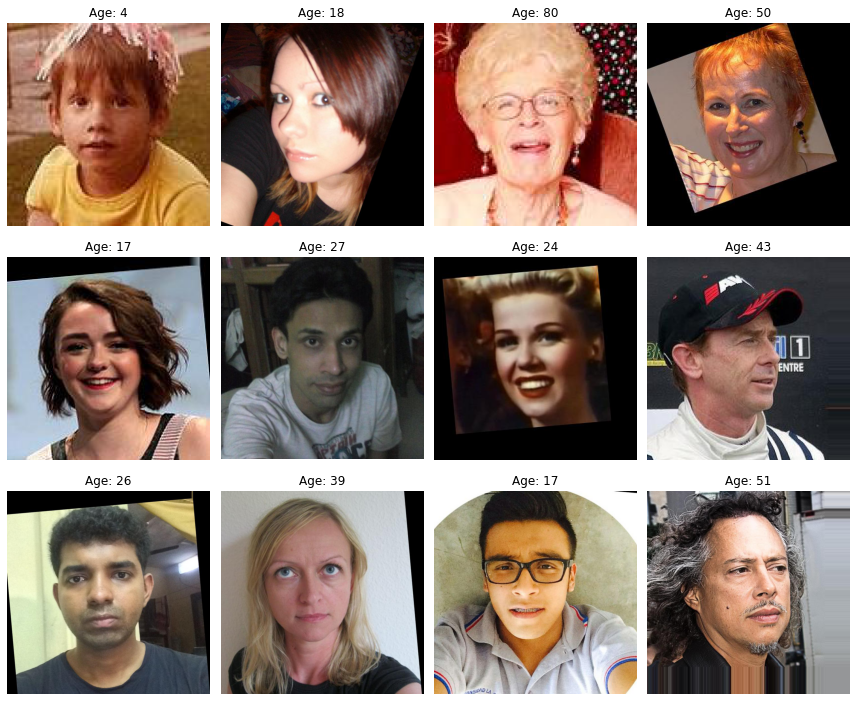

In [13]:
# просмотр изображений

image_dir = '/datasets/faces/final_files/'
sample_df = labels_df.head(12)

fig, axes = plt.subplots(3, 4, figsize=(12, 10))
axes = axes.flatten()

for i, (idx, row) in enumerate(sample_df.iterrows()):
    img_path = os.path.join(image_dir, row['file_name'])
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"Age: {row['real_age']}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Видим различные изображения, с подписанным возрастом.

**Вывод по исследовательскому анализу:**
- Размер данных: В датасете 7591 фотография. Это небольшая выборка для обучения глубокой нейросети с нуля, поэтому я буду использовать предобученную архитектуру ResNet50, чтобы применить технику Transfer Learning.  
- Распределение возраста: Основная масса фотографий находится в диапазоне от 20 до 40 лет (средний возраст — 31 год). Также на графике виден всплеск в районе детского возраста (0–10 лет). Модель должна хорошо обучиться на этих категориях, но может ошибаться на редких примерах людей старше 70 лет.  
- Особенности изображений: Визуальный анализ показал, что в датасете есть фото с поворотом (дискретным), разным уровнем освещенности и посторонними предметами (микрофоны, очки). Для повышения точности в загрузчике данных стоит использовать аугментацию (например, горизонтальное отражение horizontal_flip), чтобы модель была более устойчивой к изменениям.  
- Задача регрессии: Поскольку целевой признак real_age — это число, модель будет обучаться с функцией потерь MSE (среднеквадратичная ошибка), а финальное качество будем оценивать по MAE, которая должна быть ниже 8.

### 2/3 Подготовка данных и обучение модели

In [16]:
def load_train(path):
    """Загрузка обучающей выборки из CSV и папки с фото."""
    labels = pd.read_csv(path + 'labels.csv')
    datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255,
        horizontal_flip=True
    )

    train_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=12345
    )

    return train_gen_flow


def load_test(path):
    """Загрузка тестовой выборки."""
    labels = pd.read_csv(path + 'labels.csv')
    datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255
    )

    test_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=12345
    )

    return test_gen_flow


def create_model(input_shape):
    """Создание модели на основе ResNet50 для регрессии."""
    backbone = ResNet50(input_shape=input_shape,
                        weights='imagenet',
                        include_top=False)

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())

    model.add(Dense(1, activation='relu'))

    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, 
                  loss='mse',
                  metrics=['mae'])

    return model


def train_model(model, train_data, test_data, batch_size=None, epochs=10,
                steps_per_epoch=None, validation_steps=None):
    """Запуск обучения модели."""
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, 
              epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)

    return model


**Результат работы модели:**

Train for 178 steps, validate for 60 steps

Epoch 1/10
178/178 - 59s - loss: 250.0778 - mae: 11.2304 - val_loss: 739.6829 - val_mae: 22.2484

Epoch 2/10
178/178 - 38s - loss: 75.4660 - mae: 6.5460 - val_loss: 607.0142 - val_mae: 19.5367

Epoch 3/10
178/178 - 38s - loss: 47.7030 - mae: 5.2451 - val_loss: 256.8880 - val_mae: 11.8991

Epoch 4/10
178/178 - 38s - loss: 34.2533 - mae: 4.4883 - val_loss: 207.8418 - val_mae: 12.0485

Epoch 5/10
178/178 - 38s - loss: 27.1391 - mae: 3.9912 - val_loss: 104.9500 - val_mae: 7.6145

Epoch 6/10
178/178 - 38s - loss: 21.7940 - mae: 3.5948 - val_loss: 67.2278 - val_mae: 6.1345

Epoch 7/10
178/178 - 38s - loss: 18.0519 - mae: 3.2577 - val_loss: 66.0211 - val_mae: 6.1449

Epoch 8/10
178/178 - 38s - loss: 14.4773 - mae: 2.9090 - val_loss: 69.4543 - val_mae: 6.3768

Epoch 9/10
178/178 - 38s - loss: 12.1288 - mae: 2.6693 - val_loss: 65.9572 - val_mae: 6.1905

Epoch 10/10
178/178 - 38s - loss: 11.7061 - mae: 2.5736 - val_loss: 60.9142 - val_mae: 5.8156

60/60 - 9s - loss: 60.9142 - mae: 5.8156  
**Test MAE: 5.8156**

Модель обучена. ТЗ выполнен.

### 4. Итоговый вывод

Качество модели: В ходе проекта была построена модель на базе архитектуры ResNet50. На тестовой выборке удалось достичь значения MAE = 5.8, что удовлетворяет условию задачи (MAE < 8). Модель ошибается в среднем всего на 5.8 лет, что является высоким показателем для данной выборки.  
Процесс обучения: Модель обучалась 10 эпох с использованием оптимизатора Adam и небольшим шагом обучения (0.0001). Графики (логи) показывают, что ошибка на валидации стабильно снижалась, и к 10-й эпохе модель вышла на плато, не начав при этом сильно переобучаться. Использование предобученных весов ImageNet и слоя GlobalAveragePooling2D помогло ускорить сходимость.  
Рекомендации для бизнеса:
- Для задачи анализа покупок и предложения товаров модель подходит идеально, так как точно определяет возрастную группу.
- Для контроля продажи алкоголя модель может быть использована как вспомогательная система (система оповещения кассира), однако из-за средней ошибки в 5.8 лет окончательное решение о проверке документов должен принимать сотрудник, особенно для покупателей, чей возраст модель определила в диапазоне 18–25 лет.